In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Does Okun's Law Still Hold? (2005–2025)

**Okun's law** says that output growth and unemployment move in opposite directions. When real GDP grows, firms hire more workers and unemployment falls. When GDP shrinks, firms cut jobs and unemployment rises.

This notebook tests the law over the last 20 years. It regresses the quarterly change in the unemployment rate on quarterly real GDP growth:

$$\Delta u_t = \alpha + \beta \, g_t + \varepsilon_t$$

**Expectation:** $\beta$ will be negative and statistically significant, around **−0.4 to −0.5**. The 2008 recession and COVID-19 are the two biggest tests. They should add noise but not flip the sign.

**Data:** Federal Reserve Economic Data (FRED), St. Louis Fed:
- `UNRATE`: civilian unemployment rate (monthly, percent, seasonally adjusted)
- `GDPC1`: real gross domestic product (quarterly, billions of chained 2017 dollars, seasonally adjusted annual rate)

## Step 1: Setup

Load the other libraries and set the sample window. The download starts one quarter early, in 2004 Q4. Taking first differences drops the first quarter, so the starting quarter of the regression sample is 2005 Q1.

In [2]:
import os

import statsmodels.api as sm
from dotenv import load_dotenv
from fredapi import Fred

DOWNLOAD_START = "2004-10-01"
DOWNLOAD_END = "2025-12-31"
SOURCE_NOTE = "Source: FRED, St. Louis Fed (UNRATE, GDPC1)"
COLORS = {"data": "#2a78d6", "highlight": "#eb6834", "ink": "#0b0b0b", "muted": "#52514e"}

## Step 2: Connect to FRED

The API key is read from the `.env` file (variable `FRED_API_KEY`). The notebook never prints or displays it.

In [3]:
load_dotenv()
fred_api_key = os.getenv("FRED_API_KEY")
if not fred_api_key:
    raise RuntimeError("FRED_API_KEY is not set. Add it to the .env file in this folder.")
fred = Fred(api_key=fred_api_key)

## Step 3: Download the two series

The same download is used for both series, so it is wrapped in a function.

In [4]:
def fetch_fred_series(series_id, name):
    """Download one FRED series for the sample window and return it as a named Series."""
    series = fred.get_series(series_id, observation_start=DOWNLOAD_START, observation_end=DOWNLOAD_END)
    series.index = pd.to_datetime(series.index)
    return series.rename(name)


unemployment_monthly = fetch_fred_series("UNRATE", "unemployment_rate")
real_gdp_quarterly = fetch_fred_series("GDPC1", "real_gdp")

print(f"UNRATE: {len(unemployment_monthly)} monthly observations, "
      f"{unemployment_monthly.index.min():%Y-%m} to {unemployment_monthly.index.max():%Y-%m}")
print(f"GDPC1:  {len(real_gdp_quarterly)} quarterly observations, "
      f"{real_gdp_quarterly.index.min():%Y-%m} to {real_gdp_quarterly.index.max():%Y-%m}")

UNRATE: 255 monthly observations, 2004-10 to 2025-12
GDPC1:  85 quarterly observations, 2004-10 to 2025-10


## Step 4: Align the frequencies

GDP is quarterly but unemployment is monthly. The standard approach is to average the three monthly unemployment rates in each quarter: `resample("QS").mean()` gives one value per quarter, dated at the quarter start, which matches FRED's dating of GDPC1.

The notebook also counts how many months go into each quarterly average, so it can flag any quarter built from fewer than three months.

In [5]:
unemployment_quarterly = unemployment_monthly.resample("QS").mean()
months_per_quarter = unemployment_monthly.resample("QS").count().rename("months_observed")

incomplete_quarters = months_per_quarter[months_per_quarter < 3]
print("Quarters with fewer than 3 monthly unemployment readings:")
print(incomplete_quarters.to_string() if not incomplete_quarters.empty else "None")

Quarters with fewer than 3 monthly unemployment readings:
2025-10-01    2
Freq: QS-JAN


October 2025 is missing from `UNRATE` because the BLS did not run its household survey during the federal government shutdown. The 2025 Q4 average therefore uses November and December only. Unemployment changes slowly, so the quarter is kept, and the `flag_partial_quarter` column marks it.

## Step 5: Merge and check for missing values

Join the two quarterly series on the quarter start date. An outer join keeps every quarter from either series, so any gaps show up as missing values instead of being dropped silently.

In [6]:
quarterly = pd.concat([unemployment_quarterly, real_gdp_quarterly, months_per_quarter], axis=1, join="outer")
quarterly["flag_partial_quarter"] = quarterly["months_observed"] < 3

print("Missing values per column after the merge:")
print(quarterly[["unemployment_rate", "real_gdp"]].isna().sum().to_string())
quarterly = quarterly.dropna(subset=["unemployment_rate", "real_gdp"])

Missing values per column after the merge:
unemployment_rate    0
real_gdp             0


## Step 6: Transform the series

- **Unemployment change** ($\Delta u_t$): the first difference of the quarterly unemployment rate, in percentage points.
- **Real GDP growth** ($g_t$): the quarter-over-quarter percent change in real GDP, *not* annualized.

Both variables are measured over the same one-quarter horizon, so $\beta$ can be compared directly with the textbook Okun coefficient of about −0.5. Annualizing GDP growth would divide the coefficient by roughly four.

In [7]:
quarterly["unemployment_change"] = quarterly["unemployment_rate"].diff()
quarterly["gdp_growth"] = quarterly["real_gdp"].pct_change() * 100

okun_data = quarterly.dropna(subset=["unemployment_change", "gdp_growth"])
print(f"Regression sample: {len(okun_data)} quarters, "
      f"{okun_data.index.min():%Y-%m} to {okun_data.index.max():%Y-%m}")
okun_data[["unemployment_rate", "unemployment_change", "gdp_growth"]].describe().round(2)

Regression sample: 84 quarters, 2005-01 to 2025-10


,unemployment_rate,unemployment_change,gdp_growth
count,84.00,84.00,84.00
mean,5.74,-0.01,0.52
std,2.11,1.18,1.36
min,3.53,-4.20,-7.88
25%,4.16,-0.20,0.29
50%,4.95,-0.08,0.62
75%,7.01,0.04,0.87
max,13.00,9.17,7.76


## Step 7: Plot both series over time

The two variables use different units, so they are shown in two stacked panels with a shared time axis instead of on one chart with two y-axes. The 2008–09 recession and the 2020 COVID shock are the large moves.

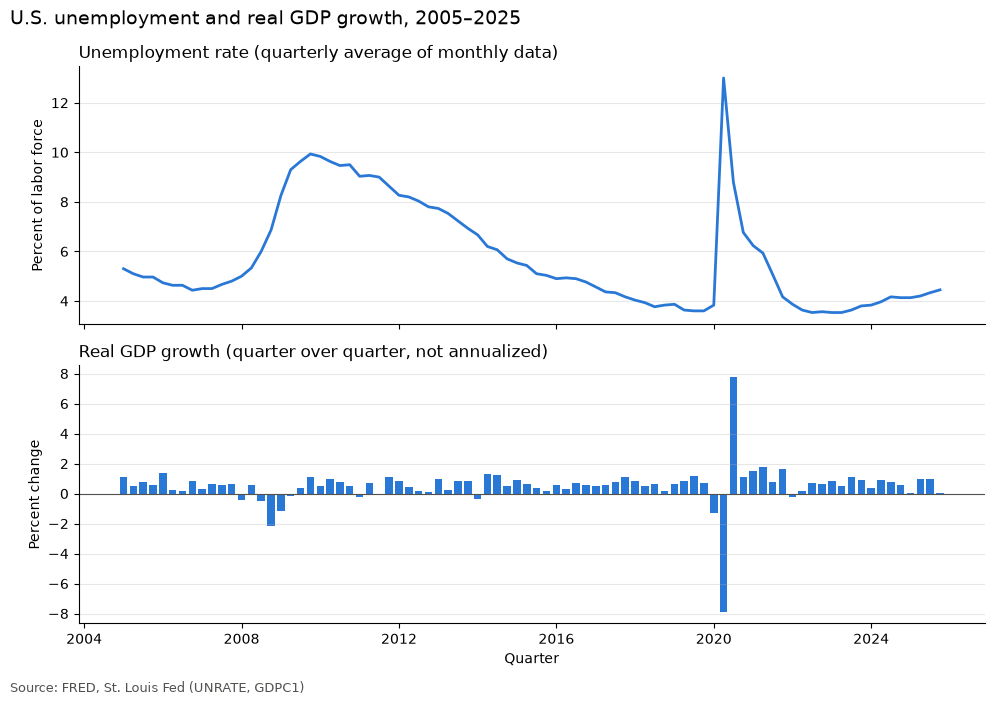

In [8]:
def plot_time_series(data):
    """Stacked line charts of the quarterly unemployment rate and real GDP growth."""
    fig, (ax_unemployment, ax_growth) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax_unemployment.plot(data.index, data["unemployment_rate"], color=COLORS["data"], linewidth=2)
    ax_unemployment.set_title("Unemployment rate (quarterly average of monthly data)", loc="left")
    ax_unemployment.set_ylabel("Percent of labor force")

    ax_growth.bar(data.index, data["gdp_growth"], width=70, color=COLORS["data"])
    ax_growth.axhline(0, color=COLORS["muted"], linewidth=0.8)
    ax_growth.set_title("Real GDP growth (quarter over quarter, not annualized)", loc="left")
    ax_growth.set_ylabel("Percent change")
    ax_growth.set_xlabel("Quarter")

    for ax in (ax_unemployment, ax_growth):
        ax.grid(axis="y", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("U.S. unemployment and real GDP growth, 2005–2025", fontsize=14, x=0.01, ha="left")
    fig.text(0.01, 0.005, SOURCE_NOTE, fontsize=9, color=COLORS["muted"])
    fig.tight_layout(rect=(0, 0.02, 1, 1))
    plt.show()


plot_time_series(okun_data)

## Step 8: OLS regression

Estimate $\Delta u_t = \alpha + \beta g_t + \varepsilon_t$ with `statsmodels` and report the coefficient, its p-value, and R². The plan expects COVID to be an outlier, so the same regression is also run without the four 2020 quarters to check whether 2020 drives the result. Both runs use the same fitting function.

In [9]:
def fit_okun_regression(data):
    """OLS of the quarterly change in unemployment on real GDP growth."""
    regressors = sm.add_constant(data["gdp_growth"])
    return sm.OLS(data["unemployment_change"], regressors).fit()


def summarize_regression(results, sample_label):
    """Pull out the statistics the plan asks for."""
    return {
        "sample": sample_label,
        "quarters": int(results.nobs),
        "okun_coefficient": results.params["gdp_growth"],
        "p_value": results.pvalues["gdp_growth"],
        "intercept": results.params["const"],
        "r_squared": results.rsquared,
    }


is_2020 = okun_data.index.year == 2020
full_sample_fit = fit_okun_regression(okun_data)
excluding_2020_fit = fit_okun_regression(okun_data[~is_2020])

regression_table = pd.DataFrame([
    summarize_regression(full_sample_fit, "2005–2025, all quarters"),
    summarize_regression(excluding_2020_fit, "2005–2025, excluding 2020"),
]).set_index("sample")
regression_table.style.format({
    "okun_coefficient": "{:.3f}", "p_value": "{:.2g}", "intercept": "{:.3f}", "r_squared": "{:.3f}",
})

,quarters,okun_coefficient,p_value,intercept,r_squared
sample,,,,,
"2005–2025, all quarters",84,-0.768,1.8e-29,0.391,0.789
"2005–2025, excluding 2020",80,-0.323,3.8e-08,0.127,0.323


In [10]:
print(full_sample_fit.summary())

                             OLS Regression Results                            
Dep. Variable:     unemployment_change   R-squared:                       0.789
Model:                             OLS   Adj. R-squared:                  0.787
Method:                  Least Squares   F-statistic:                     307.1
Date:                 Fri, 02 Oct 2026   Prob (F-statistic):           1.85e-29
Time:                         17:02:18   Log-Likelihood:                -66.843
No. Observations:                   84   AIC:                             137.7
Df Residuals:                       82   BIC:                             142.5
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3909      0.064      6.15

## Step 9: Scatter plot with fitted regression lines

Each dot is one quarter. The 2020 quarters are highlighted and labeled. The solid line is the full-sample fit and the dashed line is the fit without 2020. Outside 2020, almost every quarter falls inside a small cluster near the origin, so the few extreme quarters have a lot of leverage on the slope.

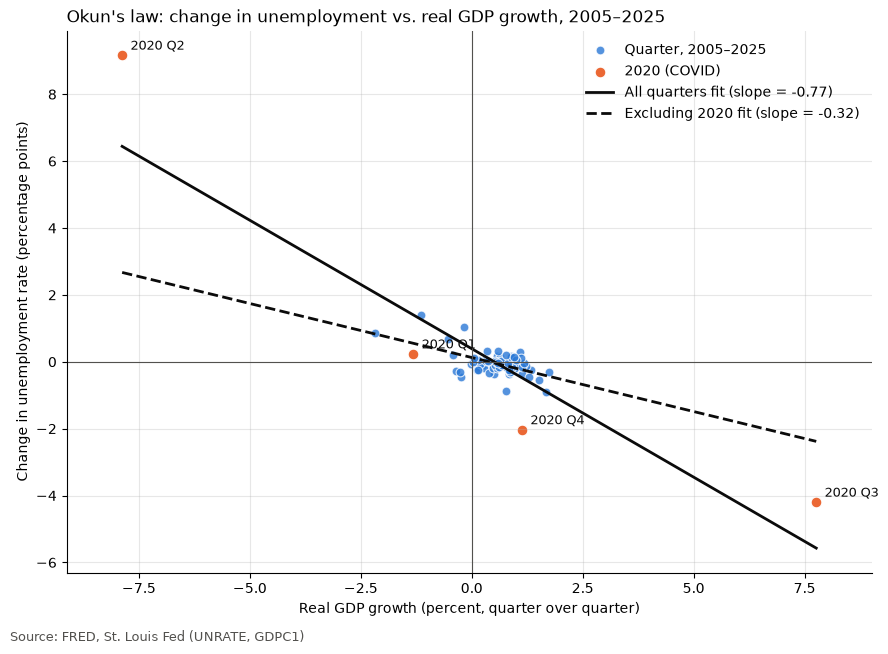

In [11]:
def add_fit_line(ax, results, x_values, label, linestyle):
    """Draw the fitted regression line implied by an OLS result."""
    fitted = results.params["const"] + results.params["gdp_growth"] * x_values
    ax.plot(x_values, fitted, color=COLORS["ink"], linewidth=2, linestyle=linestyle, label=label)


def plot_okun_scatter(data, highlight_mask, fits):
    """Scatter of unemployment change vs. GDP growth with highlighted outliers and fit lines."""
    fig, ax = plt.subplots(figsize=(9, 6.5))

    ax.scatter(data.loc[~highlight_mask, "gdp_growth"], data.loc[~highlight_mask, "unemployment_change"],
               s=40, color=COLORS["data"], alpha=0.8, edgecolor="white", linewidth=0.8,
               label="Quarter, 2005–2025")
    highlighted = data[highlight_mask]
    ax.scatter(highlighted["gdp_growth"], highlighted["unemployment_change"],
               s=60, color=COLORS["highlight"], edgecolor="white", linewidth=0.8, label="2020 (COVID)")
    for date, row in highlighted.iterrows():
        ax.annotate(f"{date.year} Q{date.quarter}", (row["gdp_growth"], row["unemployment_change"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=9, color=COLORS["ink"])

    x_values = np.linspace(data["gdp_growth"].min(), data["gdp_growth"].max(), 100)
    for (label, results), linestyle in zip(fits.items(), ["-", "--"]):
        slope = results.params["gdp_growth"]
        add_fit_line(ax, results, x_values, f"{label} fit (slope = {slope:.2f})", linestyle)

    ax.margins(x=0.08)
    ax.axhline(0, color=COLORS["muted"], linewidth=0.8)
    ax.axvline(0, color=COLORS["muted"], linewidth=0.8)
    ax.set_title("Okun's law: change in unemployment vs. real GDP growth, 2005–2025", loc="left")
    ax.set_xlabel("Real GDP growth (percent, quarter over quarter)")
    ax.set_ylabel("Change in unemployment rate (percentage points)")
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="upper right")
    fig.text(0.01, 0.005, SOURCE_NOTE, fontsize=9, color=COLORS["muted"])
    fig.tight_layout(rect=(0, 0.02, 1, 1))
    plt.show()


plot_okun_scatter(okun_data, is_2020, {"All quarters": full_sample_fit, "Excluding 2020": excluding_2020_fit})

## Conclusion

Results below are for FRED data downloaded in October 2026.

| Sample | Okun coefficient $\beta$ | p-value | R² |
|---|---|---|---|
| All quarters (2005 Q1–2025 Q4, n = 84) | −0.77 | < 0.001 | 0.79 |
| Excluding 2020 (n = 80) | −0.32 | < 0.001 | 0.32 |

**Does Okun's law still hold?** The direction does. In both samples the coefficient is negative and highly significant: faster real GDP growth goes with falling unemployment. The size of the coefficient matches the expected −0.4 to −0.5 less well:

- With every quarter included, $\beta = -0.77$, steeper than expected, and R² is unusually high.
- Without 2020, $\beta = -0.32$, a bit flatter than expected. A 1 percent rise in quarterly real GDP goes with about a 0.3 percentage point fall in unemployment.

The plan expected COVID to add noise. It did more than that: it dominated the fit. In 2020 Q2, GDP fell 7.9% in one quarter and unemployment jumped about 9 points. In Q3 most of that reversed. These two points sit far from everything else, so they pull the slope steeper and inflate R². The 2008–09 recession fits the pattern without trouble.

**Limitations**
- **The 2020 COVID outlier.** Lockdowns caused temporary layoffs and a mechanical rebound. That is not the usual demand-driven labor adjustment Okun's law describes, and the headline estimate depends heavily on whether 2020 is included.
- **A simple bivariate model.** There are no lags, even though unemployment usually responds to output with a delay. There are no controls for labor-force participation or productivity. The results describe an association, not a causal effect.
- **A small sample.** There are 84 quarters, and most of them are calm expansions with little variation in growth.
- **Default standard errors.** The residuals are clearly non-normal and probably heteroskedastic, so the p-values rely on the default (non-robust) standard errors. Robust standard errors would be a natural check.
- **Data caveats.** GDP is revised over time, so results can change with the data vintage. The 2025 Q4 unemployment average uses only two months because October 2025 was not collected during the government shutdown.
- **The difference form only.** The "gap" version of Okun's law needs an estimate of potential GDP and is not tested here.